(335, 612)


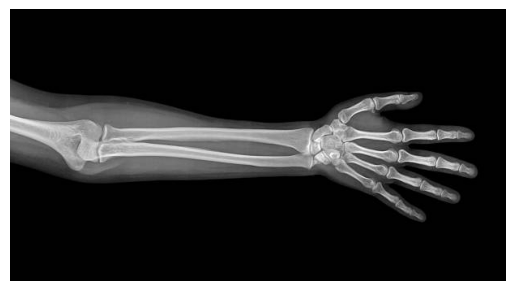

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('data/xray.jpg', cv2.IMREAD_GRAYSCALE)
print(image.shape)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

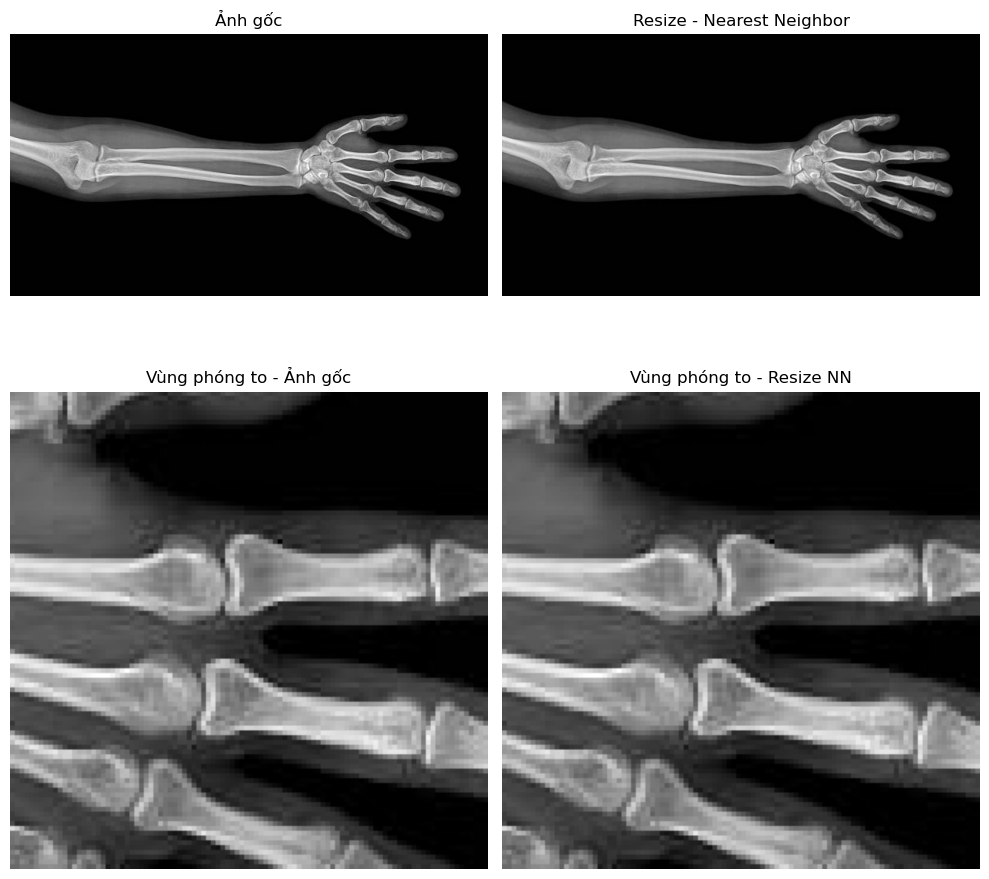

In [6]:
import numpy as np

resized_nearest = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)

h, w = image.shape
crop_size = 100
crop_y = h // 2 - crop_size // 2
crop_x = int(w * 0.8) - crop_size // 2

zoom_original = cv2.resize(image[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size], (200, 200), interpolation=cv2.INTER_NEAREST)
zoom_resized = cv2.resize(resized_nearest[crop_y*2:(crop_y+crop_size)*2, crop_x*2:(crop_x+crop_size)*2], (200, 200), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

axes[0, 1].imshow(resized_nearest, cmap='gray')
axes[0, 1].set_title('Resize - Nearest Neighbor')
axes[0, 1].axis('off')

axes[1, 0].imshow(zoom_original, cmap='gray')
axes[1, 0].set_title('Vùng phóng to - Ảnh gốc')
axes[1, 0].axis('off')

axes[1, 1].imshow(zoom_resized, cmap='gray')
axes[1, 1].set_title('Vùng phóng to - Resize NN')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

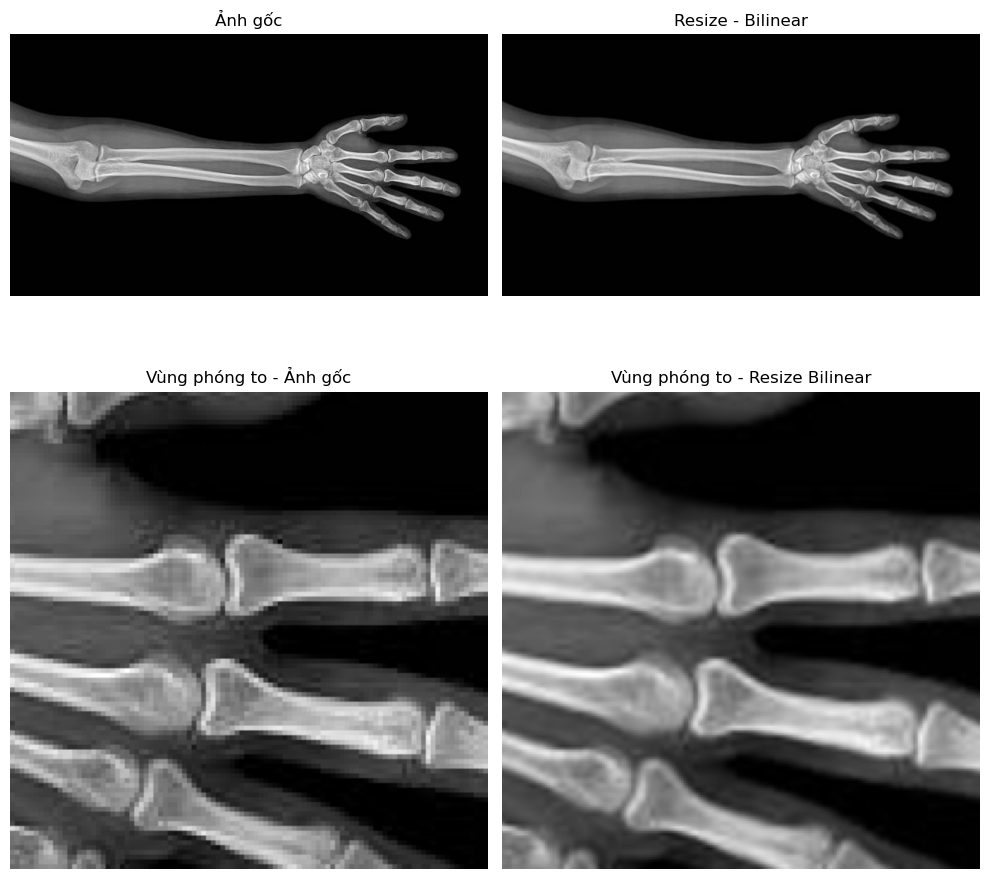

In [7]:
resized_bilinear = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)

zoom_original = cv2.resize(image[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size], (200, 200), interpolation=cv2.INTER_NEAREST)
zoom_resized = cv2.resize(resized_bilinear[crop_y*2:(crop_y+crop_size)*2, crop_x*2:(crop_x+crop_size)*2], (200, 200), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

axes[0, 1].imshow(resized_bilinear, cmap='gray')
axes[0, 1].set_title('Resize - Bilinear')
axes[0, 1].axis('off')

axes[1, 0].imshow(zoom_original, cmap='gray')
axes[1, 0].set_title('Vùng phóng to - Ảnh gốc')
axes[1, 0].axis('off')

axes[1, 1].imshow(zoom_resized, cmap='gray')
axes[1, 1].set_title('Vùng phóng to - Resize Bilinear')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

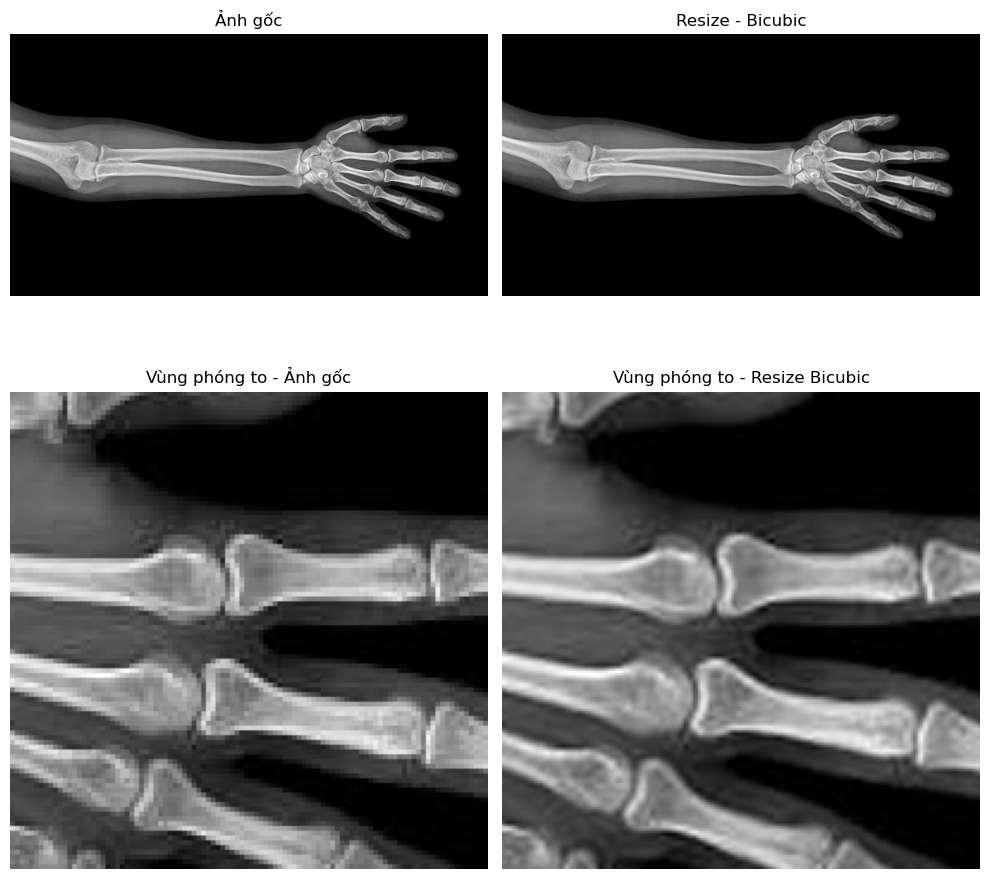

In [8]:
resized_bicubic = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

zoom_original = cv2.resize(image[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size], (200, 200), interpolation=cv2.INTER_NEAREST)
zoom_resized = cv2.resize(resized_bicubic[crop_y*2:(crop_y+crop_size)*2, crop_x*2:(crop_x+crop_size)*2], (200, 200), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

axes[0, 1].imshow(resized_bicubic, cmap='gray')
axes[0, 1].set_title('Resize - Bicubic')
axes[0, 1].axis('off')

axes[1, 0].imshow(zoom_original, cmap='gray')
axes[1, 0].set_title('Vùng phóng to - Ảnh gốc')
axes[1, 0].axis('off')

axes[1, 1].imshow(zoom_resized, cmap='gray')
axes[1, 1].set_title('Vùng phóng to - Resize Bicubic')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

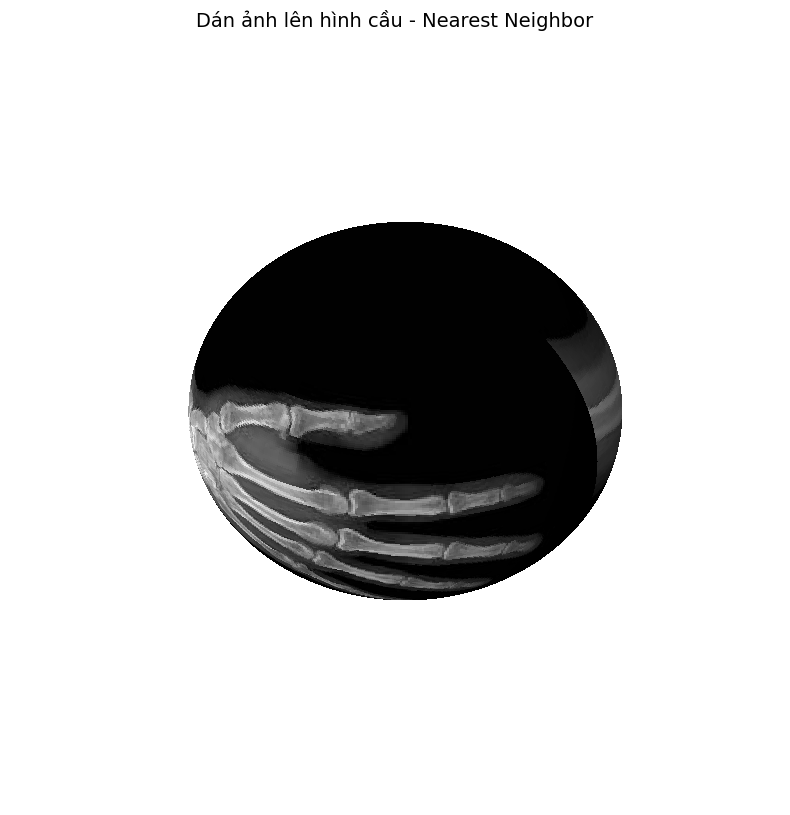

In [9]:
from mpl_toolkits.mplot3d import Axes3D

n_theta, n_phi = 300, 600
theta = np.linspace(0, np.pi, n_theta)
phi = np.linspace(0, 2 * np.pi, n_phi)
theta, phi = np.meshgrid(theta, phi)

r = 1
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

H, W = image.shape
u = (phi / (2 * np.pi)) * (W - 1)
v = (theta / np.pi) * (H - 1)

u = u.astype(np.int32)
v = v.astype(np.int32)

u = np.clip(u, 0, W - 1)
v = np.clip(v, 0, H - 1)

texture = image[v, u]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=plt.cm.gray(texture / 255), linewidth=0, antialiased=False)
ax.set_axis_off()
ax.set_title("Dán ảnh lên hình cầu - Nearest Neighbor", fontsize=14)
plt.show()